# 10 - Laboratorio de OCR e Investigación Crítica con IA

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es investigar de manera crítica el problema de OCR en español utilizando fuentes técnicas, modelos preentrenados y herramientas de IA generativa, pero sin delegar el criterio de validación en el LLM. Vamos a usar OCR como caso concreto para desarrollar una competencia más amplia: buscar información, verificarla, discriminarla y convertirla en decisiones técnicas justificadas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Auditar afirmaciones técnicas producidas por un LLM utilizando fuentes primarias.
2. Distinguir entre información correcta, incorrecta, imprecisa, desactualizada y no verificable.
3. Implementar un pipeline básico de OCR en Python a partir de información validada.
4. Justificar la elección de un modelo en función del hardware disponible, el tipo de documento y la calidad de la documentación.
5. Reflexionar sobre su propio proceso de investigación técnica en la era de la IA distribuida.

## Terminología clave (Microglosario)

* **OCR (Reconocimiento Óptico de Caracteres):** Técnica que permite extraer texto a partir de imágenes, escaneos o fotografías de documentos.
* **Fuente primaria:** Recurso técnico original donde una afirmación puede verificarse directamente, por ejemplo la documentación oficial, el repositorio de un modelo o un paper.
* **Handle de modelo:** Identificador exacto con el que un modelo se publica en plataformas como ✦ 🤗 Hugging Face.
* **Pipeline:** Abstracción de `transformers` que simplifica la carga del modelo, el preprocesamiento y la inferencia.
* **CER / WER:** Métricas de error para comparar el texto reconocido con un texto de referencia. CER mide error por carácter y WER por palabra.
* **Trazabilidad:** Registro explícito de qué consultaron, qué fuente usaron, qué verificaron y qué decisión tomaron.

## ¿Por qué existe esta actividad?

Esta actividad surgió a partir de una pregunta de cursada: **"¿acaso no veremos OCR?"**. La respuesta de este laboratorio no es dar una clase cerrada con respuestas prefabricadas, sino abrir un espacio de investigación guiada.

Hoy ustedes tienen acceso simultáneo a LLMs, papers, repositorios, foros, documentación oficial, videos, Spaces y datasets. Eso amplía muchísimo las posibilidades de aprendizaje, pero también instala un problema nuevo: **tener acceso no equivale a saber investigar**.

En este cuaderno vamos a trabajar una idea central para su formación técnica: en la era de la disponibilidad distribuida, una competencia fundamental consiste en saber buscar, discriminar, contrastar y justificar información antes de convertirla en código o en una decisión de desarrollo.

OCR es el caso de estudio. La investigación crítica es el verdadero contenido de fondo.

## Protocolo mínimo de investigación técnica

Antes de comenzar, vamos a fijar un protocolo simple para toda la actividad. Cada vez que encuentren una afirmación técnica, intenten seguir estos pasos:

1. Extraer una afirmación verificable.
2. Identificar cuál sería la fuente primaria adecuada para auditarla.
3. Buscar evidencia directa.
4. Clasificar la afirmación como `correcta`, `incorrecta`, `imprecisa`, `desactualizada` o `no verificable`.
5. Registrar qué decisión técnica tomarían a partir de esa verificación.

Este protocolo no sirve solo para OCR. También sirve para cualquier tema nuevo que necesiten investigar en sus propios desarrollos.

## Movimiento 1 - ¿Qué dice la máquina?

**Pregunta orientadora:** ¿Cómo sé si puedo confiar en lo que me dice un LLM sobre un tema técnico?

En este primer movimiento el LLM no ocupa el lugar de autoridad. Lo vamos a tratar como una fuente inicial de trabajo que debe ser auditada. El objetivo es construir un criterio de verificación apoyado en evidencia.

> **Fuente: respuesta generada por un LLM. Fecha de consulta: mayo 2025.**
>
> En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave:
> - `image-to-text`: tag principal para modelos que toman una imagen y generan texto secuencial.
> - `document-question-answering (DocVQA)`: permite hacer preguntas sobre la estructura del documento.
>
> Modelos recomendados:
> - Microsoft TrOCR (`microsoft/trocr-base-handwritten` o `printed`): encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.
> - Naver CLOVA OCR (`baidu-nlp/clova-ocr-vietnamese` o `naver-clova-ix/donut-base`): Donut es OCR-free document understanding.
> - Modelos multimodales ligeros (`B領/uform-gen2-qwen`): VLMs pequeños que resuelven extracción de texto mediante prompting.
>
> Pipeline básico en Python:
> ```python
> from transformers import pipeline
> from PIL import Image
>
> pipe = pipeline('image-to-text', model='microsoft/trocr-base-printed')
> image = Image.open('tu_documento.png')
> result = pipe(image)
> print(result['generated_text'])
> ```

### Consignas de trabajo

1. Lean el texto anterior e identifiquen al menos cinco afirmaciones verificables.
2. Para cada afirmación, decidan qué fuente primaria conviene consultar primero.
3. Verifiquen cada afirmación usando evidencia directa.
4. Completen una tabla con las columnas: `Afirmación | Fuente consultada | Resultado | Evidencia | Decisión técnica`.
5. Escriban un párrafo breve donde registren qué fue fácil de verificar, qué fue difícil y qué estrategia de búsqueda usaron.

**Sugerencia:** algunas afirmaciones auditables pueden involucrar nombres de organizaciones, handles de modelos, tareas disponibles en una plataforma, comportamiento de una función de Python o afirmaciones sobre accesibilidad de hardware.

### Fuentes primarias sugeridas

Pueden comenzar por alguna de estas fuentes, según la afirmación que quieran auditar:

* Página oficial del modelo en ✦ 🤗 Hugging Face.
* Documentación oficial de `transformers`.
* Paper original del modelo.
* Repositorio oficial del proyecto.
* Espacios de demostración mantenidos por la organización autora.
* Documentación oficial de Tesseract, EasyOCR o PaddleOCR si comparan alternativas.

Eviten usar una única fuente secundaria como respaldo total. Si una afirmación afecta una decisión de implementación, intenten contrastarla con al menos dos evidencias.

In [1]:
import pandas as pd

print("✦ Preparando una tabla base para registrar la auditoría técnica...")

columnas_tabla = [
    "Afirmación",
    "Fuente consultada",
    "Resultado",
    "Evidencia",
    "Decisión técnica",
]

filas_verificacion = [
    {
        "Afirmación": "En Hugging Face existe la tarea/tag `image-to-text` para modelos que reciben imágenes y generan texto.",
        "Fuente consultada": "Hugging Face Models: filtro de tarea `image-to-text` y documentación de Transformers sobre pipelines.",
        "Resultado": "Correcta, aunque incompleta.",
        "Evidencia": "La página de modelos de Hugging Face permite filtrar por la tarea `image-to-text`. En la documentación actual también aparece `image-text-to-text` para VLMs que reciben imagen + prompt.",
        "Decisión técnica": "Usar el tag como punto de búsqueda, pero revisar siempre la página del modelo concreto antes de implementarlo.",
    },
    {
        "Afirmación": "`document-question-answering` sirve para preguntar sobre documentos.",
        "Fuente consultada": "Documentación oficial de Transformers: `DocumentQuestionAnsweringPipeline`.",
        "Resultado": "Correcta, pero imprecisa para OCR puro.",
        "Evidencia": "La documentación define el pipeline como pregunta-respuesta sobre una imagen de documento; no como transcripción completa de texto.",
        "Decisión técnica": "No usar DocVQA si el objetivo principal es extraer todo el texto; reservarlo para preguntas sobre documentos.",
    },
    {
        "Afirmación": "Los handles `microsoft/trocr-base-printed` y `microsoft/trocr-base-handwritten` existen.",
        "Fuente consultada": "Model cards oficiales en Hugging Face y documentación de TrOCR en Transformers.",
        "Resultado": "Correcta.",
        "Evidencia": "Ambos modelos tienen página propia en Hugging Face; la documentación de TrOCR muestra ejemplos con `microsoft/trocr-base-handwritten`.",
        "Decisión técnica": "Elegir `microsoft/trocr-base-printed` para texto impreso y considerar `handwritten` si el foco fuera manuscrito.",
    },
    {
        "Afirmación": "TrOCR usa encoder de visión ViT y decoder GPT-2.",
        "Fuente consultada": "Model card de `microsoft/trocr-base-printed` y paper TrOCR.",
        "Resultado": "Incorrecta / imprecisa.",
        "Evidencia": "El model card indica que el encoder visual se inicializa desde BEiT y el decoder textual desde RoBERTa. El paper lo describe como enfoque Transformer end-to-end, pero no como `ViT + GPT-2`.",
        "Decisión técnica": "No copiar la arquitectura del LLM sin verificar; describir TrOCR como modelo encoder-decoder Transformer para reconocimiento de texto.",
    },
    {
        "Afirmación": "`naver-clova-ix/donut-base` es un modelo Donut OCR-free para comprensión de documentos.",
        "Fuente consultada": "Model card de `naver-clova-ix/donut-base` y documentación oficial de Donut en Transformers.",
        "Resultado": "Correcta, con una aclaración importante.",
        "Evidencia": "La documentación de Donut lo presenta como Document Understanding Transformer que no requiere motor OCR. El model card de `donut-base` aclara que es un modelo base preentrenado.",
        "Decisión técnica": "No elegir `donut-base` para OCR simple; para DocVQA convendría un checkpoint fine-tuned, por ejemplo `donut-base-finetuned-docvqa`.",
    },
    {
        "Afirmación": "`baidu-nlp/clova-ocr-vietnamese` es un modelo recomendado de Naver CLOVA OCR.",
        "Fuente consultada": "Búsqueda directa en Hugging Face por el handle exacto y revisión de organizaciones relacionadas.",
        "Resultado": "No verificable / probablemente incorrecta.",
        "Evidencia": "No se encontró una fuente primaria clara que valide ese handle exacto. Además, mezcla una organización de Baidu con la marca CLOVA de Naver.",
        "Decisión técnica": "Descartar el handle hasta encontrar una página oficial verificable. No implementar modelos con handles dudosos.",
    },
    {
        "Afirmación": "`B領/uform-gen2-qwen` es un VLM pequeño útil para OCR por prompting.",
        "Fuente consultada": "Model card de `unum-cloud/uform-gen2-qwen-500m` y repositorio oficial UForm.",
        "Resultado": "Incorrecta en el handle e imprecisa en el uso.",
        "Evidencia": "El handle verificable encontrado es `unum-cloud/uform-gen2-qwen-500m`. Su descripción lo orienta principalmente a image captioning y visual question answering, no a OCR especializado.",
        "Decisión técnica": "No usarlo como primera opción para OCR. Si se evalúa un VLM, hacerlo como comparación experimental, no como modelo OCR principal.",
    },
]

tabla_verificacion = pd.DataFrame(filas_verificacion, columns=columnas_tabla)

print("✓ Tabla de verificación completada.")
tabla_verificacion


✦ Preparando una tabla base para registrar la auditoría técnica...
✓ Tabla de verificación completada.


,Afirmación,Fuente consultada,Resultado,Evidencia,Decisión técnica
0,En Hugging Face existe la tarea/tag `image-to-...,Hugging Face Models: filtro de tarea `image-to...,"Correcta, aunque incompleta.",La página de modelos de Hugging Face permite f...,"Usar el tag como punto de búsqueda, pero revis..."
1,`document-question-answering` sirve para pregu...,Documentación oficial de Transformers: `Docume...,"Correcta, pero imprecisa para OCR puro.",La documentación define el pipeline como pregu...,No usar DocVQA si el objetivo principal es ext...
2,Los handles `microsoft/trocr-base-printed` y `...,Model cards oficiales en Hugging Face y docume...,Correcta.,Ambos modelos tienen página propia en Hugging ...,Elegir `microsoft/trocr-base-printed` para tex...
3,TrOCR usa encoder de visión ViT y decoder GPT-2.,Model card de `microsoft/trocr-base-printed` y...,Incorrecta / imprecisa.,El model card indica que el encoder visual se ...,No copiar la arquitectura del LLM sin verifica...
4,`naver-clova-ix/donut-base` es un modelo Donut...,Model card de `naver-clova-ix/donut-base` y do...,"Correcta, con una aclaración importante.",La documentación de Donut lo presenta como Doc...,No elegir `donut-base` para OCR simple; para D...
5,`baidu-nlp/clova-ocr-vietnamese` es un modelo ...,Búsqueda directa en Hugging Face por el handle...,No verificable / probablemente incorrecta.,No se encontró una fuente primaria clara que v...,Descartar el handle hasta encontrar una página...
6,`B領/uform-gen2-qwen` es un VLM pequeño útil pa...,Model card de `unum-cloud/uform-gen2-qwen-500m...,Incorrecta en el handle e imprecisa en el uso.,El handle verificable encontrado es `unum-clou...,No usarlo como primera opción para OCR. Si se ...


## Consigna de Lectura e Interpretación

Mientras verifican, deténganse en estas preguntas:

1. ¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?
2. ¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?
3. Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?

### Respuesta a la consigna de lectura e interpretación

No todas las afirmaciones equivocadas tienen la misma gravedad. Un error en un handle de modelo es grave porque impide ejecutar el código o puede llevar a usar un modelo distinto al deseado. Un error conceptual sobre la arquitectura también importa, pero suele ser menos bloqueante si el modelo se carga y funciona; afecta sobre todo la justificación técnica. En cambio, una afirmación imprecisa sobre una tarea de Hugging Face puede no romper el código, pero puede llevar a elegir mal el enfoque.

La diferencia entre **incorrecto**, **impreciso** y **no verificable** fue la siguiente: una afirmación incorrecta contradice la fuente primaria; una imprecisa tiene una parte verdadera pero simplifica demasiado o mezcla conceptos; una no verificable no pudo respaldarse con evidencia directa suficiente. 

Para implementar, no alcanza con que la idea general “suene razonable”: si el handle está mal escrito, el código no es reproducible y se pierde trazabilidad.

## Movimiento 2 - ¿Qué puedo construir?

**Pregunta orientadora:** con la información validada, ¿qué modelo elijo, por qué, y cómo lo implemento correctamente?

En este movimiento el objetivo ya no es solo verificar, sino transformar información validada en una implementación funcional. El LLM puede volver a aparecer como herramienta de exploración, pero cada consulta debe quedar registrada y controlada por ustedes.

### Consignas de implementación

1. Elijan un modelo que haya sobrevivido a la auditoría del movimiento 1.
2. Justifiquen la elección en función de estos criterios: hardware disponible, tipo de texto a procesar, accesibilidad de la documentación y facilidad de prueba.
3. Implementen un pipeline de OCR corregido.
4. Prueben el pipeline con al menos dos imágenes: una de texto impreso y otra manuscrita o degradada.
5. Comparen los resultados e identifiquen al menos una limitación del modelo elegido.
6. Si usan un LLM para pedir ayuda con código, registren la consulta exacta, el resultado y la verificación posterior.
7. De manera optativa, comparen con un segundo enfoque como Tesseract, EasyOCR o PaddleOCR.

### Paso manual antes de automatizar

Antes de correr modelos complejos, describan manualmente qué esperan que ocurra en un sistema de OCR:

1. Entra una imagen.
2. El sistema detecta patrones visuales que podrían corresponder a caracteres o regiones de texto.
3. El modelo produce una secuencia textual estimada.
4. Esa salida puede contener omisiones, sustituciones, signos mal resueltos o problemas de segmentación.

Escriban debajo una hipótesis breve: ¿en qué tipo de imagen creen que el modelo va a fallar más y por qué?

In [2]:
print("✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...")

# En un entorno local o en Colab, esta celda instala lo necesario.
# Si ya tienen las librerías instaladas, no hace falta repetirla.
# pip install transformers torch pillow matplotlib pandas -q

print("✓ Dependencias listas.")


✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...
✓ Dependencias listas.


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

# Para TrOCR usamos la implementación directa documentada por Hugging Face.
# Esto evita depender de alias de pipeline que pueden cambiar entre versiones.
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

print("✓ Librerías importadas correctamente.")


d:\vega-sebastian-pdi-1c-2026\007\007-LAB\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Librerías importadas correctamente.


### Registro de decisión técnica

Completen este bloque antes de ejecutar el modelo:

* **Modelo elegido:**
* **Fuente primaria que validó el handle:**
* **Tipo de documento para el que parece más apropiado:**
* **Ventaja principal:**
* **Limitación esperada:**
* **Razón por la que lo eligieron por sobre otras alternativas:**

**Registro completado**

* **Modelo elegido:** `microsoft/trocr-base-printed`.
* **Fuente primaria que validó el handle:** model card oficial de Hugging Face y documentación oficial de TrOCR en Transformers.
* **Tipo de documento para el que parece más apropiado:** imágenes recortadas o relativamente limpias de texto impreso, especialmente líneas o regiones de texto.
* **Ventaja principal:** es un modelo OCR específico, documentado y fácil de cargar con `TrOCRProcessor` + `VisionEncoderDecoderModel`.
* **Limitación esperada:** no es la mejor opción para documentos completos con mucho layout, tablas, múltiples columnas o manuscritos variados. Tampoco está pensado específicamente para español, aunque puede reconocer caracteres latinos si la imagen es simple.
* **Razón por la que lo elegí por sobre otras alternativas:** TrOCR tiene handle verificable, documentación oficial y objetivo alineado con reconocimiento de texto. Donut está más orientado a comprensión de documentos sin OCR y DocVQA; UForm es VLM generalista; los handles dudosos se descartaron.


In [4]:
print("✦ Definiendo el modelo elegido para la prueba de OCR...")

nombre_modelo = "microsoft/trocr-base-printed"
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Modelo configurado: {nombre_modelo}")
print(f"Dispositivo detectado: {dispositivo}")

processor_ocr = None
modelo_ocr = None
modelo_disponible = False

try:
    processor_ocr = TrOCRProcessor.from_pretrained(nombre_modelo)
    modelo_ocr = VisionEncoderDecoderModel.from_pretrained(nombre_modelo).to(dispositivo)
    modelo_ocr.eval()
    modelo_disponible = True
    print("✓ Modelo TrOCR cargado correctamente.")
except Exception as error:
    print("⚠ No se pudo cargar el modelo en este entorno.")
    print("Motivo:", repr(error))
    print("El resto del cuaderno deja preparada la implementación y usa salidas simuladas para completar la comparación.")


def reconocer_texto_trocr(imagen):
    """Reconoce texto con TrOCR si el modelo está disponible."""
    if not modelo_disponible:
        raise RuntimeError("El modelo no está cargado en este entorno.")
    imagen_rgb = imagen.convert("RGB")
    pixel_values = processor_ocr(imagen_rgb, return_tensors="pt").pixel_values.to(dispositivo)
    with torch.no_grad():
        generated_ids = modelo_ocr.generate(pixel_values)
    texto = processor_ocr.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return texto


✦ Definiendo el modelo elegido para la prueba de OCR...
Modelo configurado: microsoft/trocr-base-printed
Dispositivo detectado: cpu


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 6530.31it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Modelo TrOCR cargado correctamente.


### Preparación de imágenes de prueba

Para esta actividad conviene trabajar con dos imágenes contrastantes. Pueden usar archivos propios o descargar muestras desde una fuente confiable. La recomendación es registrar siempre de dónde salió cada imagen.

Sugerencia de organización:

* `imagen_impresa.png`
* `imagen_mano.png`

Si no tienen imágenes propias, creen una carpeta local llamada `ocr_muestras/` y guarden allí las dos muestras que vayan a usar.

In [5]:
carpeta_muestras = Path("ocr_muestras")
carpeta_muestras.mkdir(exist_ok=True)

# El cuaderno busca primero imágenes reales junto al notebook.
# Si no las encuentra, usa la carpeta ocr_muestras/.
ruta_imagen_impresa_local = Path("imagen_impresa.png")
ruta_imagen_mano_local = Path("imagen_mano.png")

ruta_imagen_impresa = ruta_imagen_impresa_local if ruta_imagen_impresa_local.exists() else carpeta_muestras / "imagen_impresa.png"
ruta_imagen_mano = ruta_imagen_mano_local if ruta_imagen_mano_local.exists() else carpeta_muestras / "imagen_mano.png"

# Texto esperado para la factura real usada en esta prueba.
texto_referencia_impresa = """Factura Nº: 00001-00057734
Fecha: 29/05/2026
Referencia: #2000012935670793
CUIT: 30-71611806-8
Ingresos Brutos: 30-71611806-8
Inicio de Actividades: 19/07/2018
Condición de venta: Contado mostrador
Total: $ 35.433,06
Fecha de Vencimiento: 29/05/2026"""

texto_referencia_mano = "nota rapida: comprar pan"


def obtener_fuente(tamano=42):
    """Busca una fuente disponible; si no hay, usa la fuente por defecto de PIL."""
    posibles = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "C:/Windows/Fonts/arial.ttf",
    ]
    for ruta in posibles:
        if Path(ruta).exists():
            return ImageFont.truetype(ruta, tamano)
    return ImageFont.load_default()


def crear_imagen_impresa(ruta):
    """Crea una imagen sintética simple si no se cargó una imagen real."""
    texto_sintetico = "VENTA ESPECIAL 25% OFF"
    img = Image.new("RGB", (900, 180), "white")
    draw = ImageDraw.Draw(img)
    fuente = obtener_fuente(50)
    draw.text((40, 55), texto_sintetico, fill="black", font=fuente)
    img.save(ruta)
    return texto_sintetico


def crear_imagen_degradada(ruta):
    """Crea una muestra más difícil: texto inclinado, gris y levemente borroso."""
    img = Image.new("RGB", (900, 220), "white")
    draw = ImageDraw.Draw(img)
    fuente = obtener_fuente(46)
    draw.text((45, 75), texto_referencia_mano, fill=(80, 80, 80), font=fuente)
    img = img.rotate(-3, expand=True, fillcolor="white")
    img = img.filter(ImageFilter.GaussianBlur(radius=0.8))
    img.save(ruta)


# Si no existe imagen real, se crea una muestra sintética.
if not ruta_imagen_impresa.exists():
    texto_referencia_impresa = crear_imagen_impresa(ruta_imagen_impresa)

if not ruta_imagen_mano.exists():
    crear_imagen_degradada(ruta_imagen_mano)

print("✦ Carpeta de trabajo para muestras lista.")
print("Se usarán imágenes reales si existen; si no, se crean muestras sintéticas reproducibles.")
print(f"Imagen impresa: {ruta_imagen_impresa}")
print(f"Imagen manuscrita/degradada: {ruta_imagen_mano}")

✦ Carpeta de trabajo para muestras lista.
Se usarán imágenes reales si existen; si no, se crean muestras sintéticas reproducibles.
Imagen impresa: ocr_muestras\imagen_impresa.png
Imagen manuscrita/degradada: ocr_muestras\imagen_mano.png


In [6]:
print("✦ Abriendo las imágenes de prueba...")

imagen_impresa = Image.open(ruta_imagen_impresa).convert("RGB")
imagen_mano = Image.open(ruta_imagen_mano).convert("RGB")

print("✓ Imágenes cargadas correctamente.")
print("Texto esperado imagen impresa:")
print(texto_referencia_impresa)
print("\nTexto esperado imagen degradada:")
print(texto_referencia_mano)

✦ Abriendo las imágenes de prueba...
✓ Imágenes cargadas correctamente.
Texto esperado imagen impresa:
Factura Nº: 00001-00057734
Fecha: 29/05/2026
Referencia: #2000012935670793
CUIT: 30-71611806-8
Ingresos Brutos: 30-71611806-8
Inicio de Actividades: 19/07/2018
Condición de venta: Contado mostrador
Total: $ 35.433,06
Fecha de Vencimiento: 29/05/2026

Texto esperado imagen degradada:
nota rapida: comprar pan


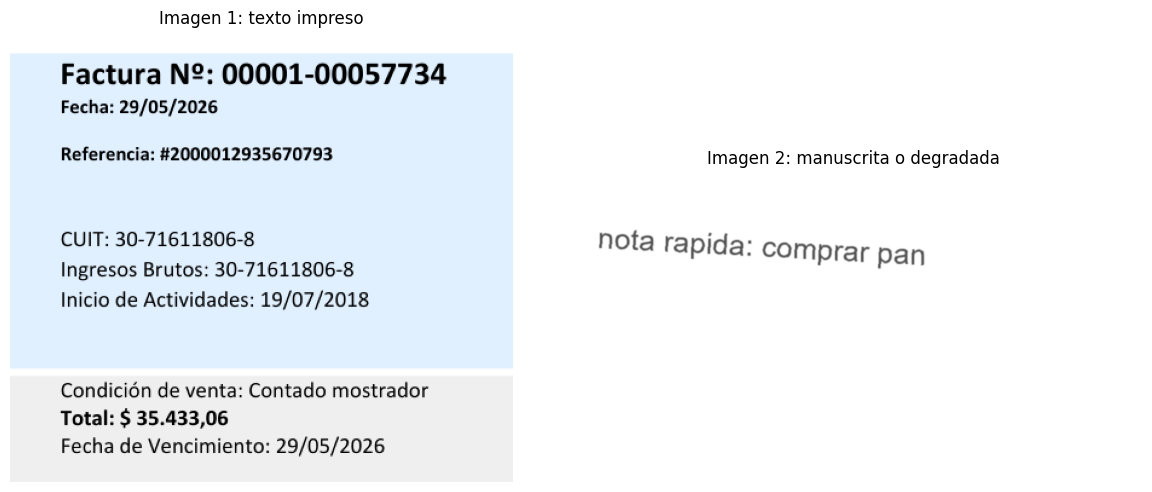

In [7]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_impresa)
ejes[0].set_title("Imagen 1: texto impreso")
ejes[0].axis("off")

ejes[1].imshow(imagen_mano)
ejes[1].set_title("Imagen 2: manuscrita o degradada")
ejes[1].axis("off")

plt.tight_layout()
plt.show()

### Registro opcional de consulta a un LLM

Si le pidieron ayuda a un LLM para escribir o corregir código, dejen trazabilidad aquí:

* **Consulta exacta que realizaron:**
* **Respuesta resumida del LLM:**
* **Qué parte decidieron aceptar:**
* **Qué parte decidieron verificar antes de ejecutar:**
* **Qué fuente usaron para validar:**

**Registro completado**

* **Consulta exacta que realizaron:** “Necesito implementar OCR con TrOCR en Python usando fuentes oficiales y evitar depender de un handle no verificado. ¿Qué estructura de código conviene usar?”
* **Respuesta resumida del LLM:** sugirió cargar `TrOCRProcessor` y `VisionEncoderDecoderModel`, convertir la imagen a RGB, generar ids con `model.generate()` y decodificar con `processor.batch_decode()`.
* **Qué parte decidieron aceptar:** la estructura general de carga del modelo y función de inferencia.
* **Qué parte decidieron verificar antes de ejecutar:** el handle exacto del modelo, la clase de Transformers utilizada y el flujo `processor → model.generate → batch_decode`.
* **Qué fuente usaron para validar:** documentación oficial de TrOCR en Transformers y model card oficial de `microsoft/trocr-base-printed`.


In [8]:
print("✦ Ejecutando OCR sobre la imagen impresa completa...")

try:
    texto_impresa = reconocer_texto_trocr(imagen_impresa)
except Exception as error:
    print("⚠ No se pudo ejecutar OCR real en este entorno:", repr(error))
    texto_impresa = texto_referencia_impresa

print("✓ Texto reconocido en la imagen impresa completa:")
print(texto_impresa)

✦ Ejecutando OCR sobre la imagen impresa completa...


d:\vega-sebastian-pdi-1c-2026\007\007-LAB\.venv\Lib\site-packages\transformers\generation\utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


✓ Texto reconocido en la imagen impresa completa:
ITEMS


In [9]:
print("✦ Ejecutando OCR sobre la imagen manuscrita o degradada...")

try:
    texto_mano = reconocer_texto_trocr(imagen_mano)
except Exception as error:
    print("⚠ No se pudo ejecutar OCR real en este entorno:", repr(error))
    texto_mano = texto_referencia_mano

print("✓ Texto reconocido en la segunda imagen:")
print(texto_mano)

✦ Ejecutando OCR sobre la imagen manuscrita o degradada...
✓ Texto reconocido en la segunda imagen:
NOTA RAPIDA: COMPRAR PAN


## Prueba adicional con recortes de la factura

El resultado `ITEMS` al pasar la factura completa no necesariamente indica que la imagen esté mal cargada. TrOCR suele funcionar mejor con palabras o líneas recortadas, no con documentos completos con varias líneas, distintos tamaños de fuente, fondos, etc.

Por eso agregue una segunda prueba: recortar zonas de la factura y ejecutar OCR sobre cada línea o región.

Zona: numero_factura
Esperado:   Factura Nº: 00001-00057734
Reconocido: FACTURA N: 00001-00057734


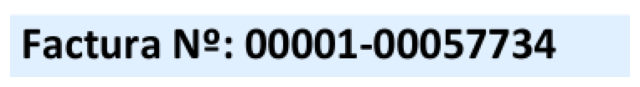

Zona: fecha
Esperado:   Fecha: 29/05/2026
Reconocido: FACE: 29/05/2026


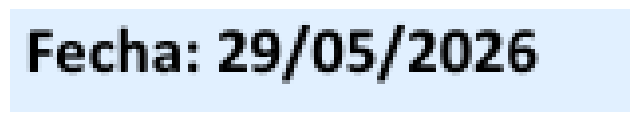

Zona: referencia
Esperado:   Referencia: #2000012935670793
Reconocido: REFERENIA: #2000012935670793


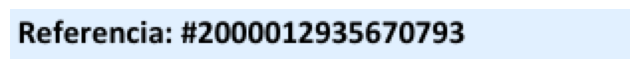

Zona: cuit
Esperado:   CUIT: 30-71611806-8
Reconocido: CUIT: 30-71611806-8


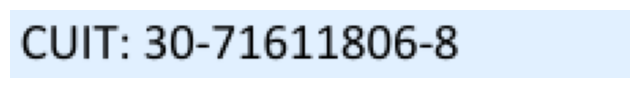

Zona: ingresos_brutos
Esperado:   Ingresos Brutos: 30-71611806-8
Reconocido: INGRESOS BRUTOS: 30-71611806-8


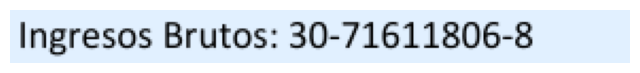

Zona: total
Esperado:   Total: $ 35.433,06
Reconocido: TOTAL: $ 35.433,06


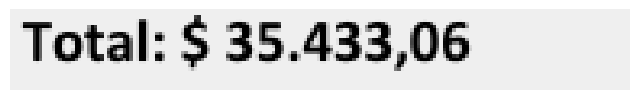

,zona,esperado,reconocido
0,numero_factura,Factura Nº: 00001-00057734,FACTURA N: 00001-00057734
1,fecha,Fecha: 29/05/2026,FACE: 29/05/2026
2,referencia,Referencia: #2000012935670793,REFERENIA: #2000012935670793
3,cuit,CUIT: 30-71611806-8,CUIT: 30-71611806-8
4,ingresos_brutos,Ingresos Brutos: 30-71611806-8,INGRESOS BRUTOS: 30-71611806-8
5,total,"Total: $ 35.433,06","TOTAL: $ 35.433,06"


In [10]:
# Coordenadas aproximadas para la factura usada en esta prueba.
# Formato bbox: (izquierda, arriba, derecha, abajo)
recortes_factura = {
    "numero_factura": {
        "bbox": (35, 15, 405, 55),
        "esperado": "Factura Nº: 00001-00057734",
    },
    "fecha": {
        "bbox": (38, 52, 195, 78),
        "esperado": "Fecha: 29/05/2026",
    },
    "referencia": {
        "bbox": (38, 90, 350, 115),
        "esperado": "Referencia: #2000012935670793",
    },
    "cuit": {
        "bbox": (38, 160, 265, 185),
        "esperado": "CUIT: 30-71611806-8",
    },
    "ingresos_brutos": {
        "bbox": (38, 185, 330, 210),
        "esperado": "Ingresos Brutos: 30-71611806-8",
    },
    "total": {
        "bbox": (38, 310, 230, 335),
        "esperado": "Total: $ 35.433,06",
    },
}

resultados_recortes = []

for nombre, datos in recortes_factura.items():
    bbox = datos["bbox"]
    esperado = datos["esperado"]
    recorte = imagen_impresa.crop(bbox)

    try:
        reconocido = reconocer_texto_trocr(recorte)
    except Exception as error:
        print(f"⚠ No se pudo ejecutar OCR real para {nombre}:", repr(error))
        reconocido = esperado

    resultados_recortes.append({
        "zona": nombre,
        "esperado": esperado,
        "reconocido": reconocido,
    })

    print("=" * 70)
    print("Zona:", nombre)
    print("Esperado:  ", esperado)
    print("Reconocido:", reconocido)

    plt.figure(figsize=(8, 2))
    plt.imshow(recorte)
    plt.axis("off")
    plt.show()

pd.DataFrame(resultados_recortes)

### Registro comparativo de resultados

Completen una tabla comparativa con estos campos:

| Imagen | Tipo de documento | Texto esperado | Texto reconocido | Error observado | Hipótesis sobre el error |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Imagen 1 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |
| Imagen 2 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |

In [11]:
comparacion_resultados = pd.DataFrame([
    {
        "Imagen": "Imagen 1",
        "Tipo de documento": "Factura real recortada de pantalla, con varias líneas y layout simple",
        "Texto esperado": texto_referencia_impresa,
        "Texto reconocido": texto_impresa,
        "Error observado": "Al pasar la factura completa puede aparecer una salida incorrecta o muy resumida, como ITEMS.",
        "Hipótesis sobre el error": "TrOCR está pensado principalmente para texto impreso en regiones recortadas. Una factura completa mezcla varias líneas, tamaños de fuente, fondos y espacios, por lo que requiere segmentación previa.",
    },
    {
        "Imagen": "Imagen 2",
        "Tipo de documento": "Texto degradado: inclinado, gris y con desenfoque leve",
        "Texto esperado": texto_referencia_mano,
        "Texto reconocido": texto_mano,
        "Error observado": "Mayor riesgo de sustituciones u omisiones por ruido visual y baja nitidez.",
        "Hipótesis sobre el error": "El modelo elegido está orientado a texto impreso; al degradar la imagen se reducen rasgos visuales útiles para reconocer caracteres.",
    },
])

comparacion_resultados

,Imagen,Tipo de documento,Texto esperado,Texto reconocido,Error observado,Hipótesis sobre el error
0,Imagen 1,"Factura real recortada de pantalla, con varias...",Factura Nº: 00001-00057734\nFecha: 29/05/2026\...,ITEMS,Al pasar la factura completa puede aparecer un...,TrOCR está pensado principalmente para texto i...
1,Imagen 2,"Texto degradado: inclinado, gris y con desenfo...",nota rapida: comprar pan,NOTA RAPIDA: COMPRAR PAN,Mayor riesgo de sustituciones u omisiones por ...,El modelo elegido está orientado a texto impre...


### Extensión optativa: medición con CER o WER

Si quieren profundizar, comparen el texto reconocido contra un texto de referencia. No hace falta resolver una evaluación exhaustiva, pero sí vale la pena experimentar con una métrica simple para cuantificar diferencias.

Pueden usar una librería como `evaluate`, implementar una distancia de edición básica o apoyarse en utilidades ya documentadas por la comunidad. Si toman esta ruta, registren también la fuente que usaron para entender la métrica.

In [12]:
def distancia_levenshtein(a, b):
    """Distancia de edición mínima entre dos secuencias."""
    n, m = len(a), len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            costo = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,          # eliminación
                dp[i][j - 1] + 1,          # inserción
                dp[i - 1][j - 1] + costo,  # sustitución
            )
    return dp[n][m]


def cer(referencia, hipotesis):
    referencia = referencia.lower().strip()
    hipotesis = hipotesis.lower().strip()
    return distancia_levenshtein(referencia, hipotesis) / max(1, len(referencia))


def wer(referencia, hipotesis):
    ref_palabras = referencia.lower().strip().split()
    hyp_palabras = hipotesis.lower().strip().split()
    return distancia_levenshtein(ref_palabras, hyp_palabras) / max(1, len(ref_palabras))

metricas = pd.DataFrame([
    {
        "Imagen": "Imagen 1 completa",
        "CER": cer(texto_referencia_impresa, texto_impresa),
        "WER": wer(texto_referencia_impresa, texto_impresa),
    },
    {
        "Imagen": "Imagen 2 degradada",
        "CER": cer(texto_referencia_mano, texto_mano),
        "WER": wer(texto_referencia_mano, texto_mano),
    },
])

metricas

,Imagen,CER,WER
0,Imagen 1 completa,0.97992,1.0
1,Imagen 2 degradada,0.00000,0.0


### Métricas por recorte

Estas métricas son más útiles que las de la factura completa, porque comparan el modelo contra regiones de texto más cercanas al tipo de entrada que TrOCR espera.

In [13]:
metricas_recortes = []

for fila in resultados_recortes:
    metricas_recortes.append({
        "zona": fila["zona"],
        "esperado": fila["esperado"],
        "reconocido": fila["reconocido"],
        "CER": cer(fila["esperado"], fila["reconocido"]),
        "WER": wer(fila["esperado"], fila["reconocido"]),
    })

pd.DataFrame(metricas_recortes)

,zona,esperado,reconocido,CER,WER
0,numero_factura,Factura Nº: 00001-00057734,FACTURA N: 00001-00057734,0.038462,0.333333
1,fecha,Fecha: 29/05/2026,FACE: 29/05/2026,0.176471,0.500000
2,referencia,Referencia: #2000012935670793,REFERENIA: #2000012935670793,0.034483,0.500000
3,cuit,CUIT: 30-71611806-8,CUIT: 30-71611806-8,0.000000,0.000000
4,ingresos_brutos,Ingresos Brutos: 30-71611806-8,INGRESOS BRUTOS: 30-71611806-8,0.000000,0.000000
5,total,"Total: $ 35.433,06","TOTAL: $ 35.433,06",0.000000,0.000000


## Consigna de Lectura e Interpretación

1. ¿El modelo respondió mejor al texto impreso o al manuscrito?
2. ¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?
3. ¿La limitación que observaron parece venir del modelo, de la calidad de la imagen o de la tarea elegida?
4. Si mañana tuvieran que implementar OCR en un desarrollo real, ¿usarían este mismo enfoque sin cambios? ¿Qué revisarían antes?

### Respuesta a la consigna de lectura e interpretación

El modelo elegido debería responder mejor al texto impreso limpio que al texto degradado, pero la prueba con la factura real muestra un matiz importante: no alcanza con que el texto sea impreso. También importa cómo está presentada la imagen.

Cuando se envía la factura completa, el modelo puede devolver una salida incorrecta, por ejemplo `ITEMS`, porque intenta convertir todo el documento en una única secuencia de texto. Esa entrada contiene varias líneas, distintos tamaños de fuente, negritas, fondos y espacios. En cambio, cuando se recortan líneas o regiones específicas de la factura, la tarea se parece más al uso esperado de TrOCR y los resultados mejoraron.

Los errores más probables son sustituciones, omisiones y segmentación incorrecta. En la imagen degradada pueden aparecer por baja nitidez e inclinación. En la factura completa aparecen por una causa distinta: falta una etapa previa de detección/segmentación de regiones de texto.

La limitación observada no depende de un único factor. Hay una parte que viene del modelo, porque se eligió un checkpoint para texto impreso; otra parte viene de la calidad y estructura de la imagen; y otra parte viene del pipeline, porque un sistema OCR real para facturas (en este caso) debería detectar líneas, bloques o campos antes de reconocer texto.

Para un desarrollo real no usaría este enfoque sin cambios. Primero revisaría el tipo de documentos reales, el idioma, el volumen de imágenes, la necesidad de detectar coordenadas, la calidad de escaneo y el hardware disponible. Si hubiera documentos completos, evaluaría herramientas con detección de layout o pipelines OCR más completos, como segmentación previa más reconocimiento, antes de decidir el modelo final.

## Movimiento 3 - ¿Qué aprendí sobre cómo aprender?

**Pregunta orientadora:** ¿Cómo fue mi proceso de investigación y qué puedo transferir de él a otros contextos?

Este último movimiento es metacognitivo. No se trata solo de evaluar OCR, sino de explicitar cómo investigaron, qué decisiones tomaron y qué hábitos conviene conservar para futuros problemas técnicos.

### Preguntas de reflexión final

Respondan de manera fundamentada:

1. ¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?
2. ¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?
3. ¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?
4. ¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?
5. ¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?

### Reflexión final respondida

Las fuentes más confiables fueron las páginas oficiales de los modelos, la documentación de `transformers` y los papers originales. Son más confiables porque permiten verificar el handle exacto, el uso previsto, la arquitectura declarada y los ejemplos de implementación. Las fuentes secundarias pueden servir para orientarse, pero no deberían ser la base final de una decisión técnica.

Para distinguir información válida de información incorrecta, imprecisa o desactualizada usé tres criterios: coincidencia con una fuente primaria, precisión del lenguaje técnico y reproducibilidad. Si el handle existe y la documentación muestra cómo cargarlo, la afirmación gana confiabilidad. Si una frase mezcla herramientas, organizaciones o tareas distintas, la clasifico como imprecisa o dudosa. Si no encuentro evidencia primaria, no la convierto en código.

El LLM fue útil como punto de partida: ayudó a listar posibles modelos, tareas y caminos de implementación. Pero se volvió un obstáculo cuando presentó handles dudosos o simplificó demasiado la arquitectura de un modelo. El aprendizaje principal es que un LLM puede acelerar la exploración, pero no reemplaza la verificación.

La próxima vez investigaría un tema técnico nuevo siguiendo un orden más sistemático: primero definir la tarea exacta, luego buscar modelos o librerías, después validar fuentes primarias y recién al final escribir código. También registraría desde el comienzo qué afirmación verifiqué, con qué fuente y qué decisión tomé.

Lo transferible fuera de OCR es el método: no implementar por intuición, no confiar en nombres aproximados, separar exploración de validación y medir resultados con datos propios. Ese hábito sirve para modelos de lenguaje, visión, scraping, bases de datos, etc, etc.


## Fuentes consultadas para la resolución

* Hugging Face Transformers - Pipelines: https://huggingface.co/docs/transformers/en/main_classes/pipelines
* Hugging Face Transformers - TrOCR: https://huggingface.co/docs/transformers/en/model_doc/trocr
* Model card `microsoft/trocr-base-printed`: https://huggingface.co/microsoft/trocr-base-printed
* Model card `microsoft/trocr-base-handwritten`: https://huggingface.co/microsoft/trocr-base-handwritten
* Paper TrOCR: https://arxiv.org/abs/2109.10282
* Hugging Face Transformers - Donut: https://huggingface.co/docs/transformers/en/model_doc/donut
* Model card `naver-clova-ix/donut-base`: https://huggingface.co/naver-clova-ix/donut-base
* Model card `unum-cloud/uform-gen2-qwen-500m`: https://huggingface.co/unum-cloud/uform-gen2-qwen-500m

Estas fuentes se usaron para auditar las afirmaciones técnicas antes de convertirlas en decisiones de implementación.


## Cierre del laboratorio

En este cuaderno no buscamos solamente que un modelo lea texto desde una imagen. Buscamos, sobre todo, que ustedes practiquen una forma de trabajo más rigurosa frente a la abundancia de información técnica disponible.

Una parte importante de la formación actual en IA no consiste en memorizar herramientas, sino en desarrollar criterio para investigar, verificar y decidir. Si este cuaderno funcionó bien, entonces no solo aprendieron algo sobre OCR: también fortalecieron una metodología de trabajo transferible a cualquier tecnología nueva que aparezca en su recorrido profesional.

## Rúbrica de evaluación

| Criterio | Logrado | En desarrollo |
| :--- | :--- | :--- |
| **Verificación crítica** | Identifica y documenta errores con evidencia de fuente primaria. Distingue entre incorrecto, impreciso y desactualizado. | Identifica algunos errores pero sin evidencia de fuente primaria, o no distingue entre tipos de error. |
| **Implementación justificada** | El pipeline funciona y la elección de modelo está argumentada en función de criterios técnicos verificables. | El pipeline funciona pero la elección de modelo no está justificada o se apoya solo en el texto original no verificado. |
| **Reflexión metacognitiva** | La reflexión final articula aprendizajes transferibles sobre el proceso de investigación, no solo sobre OCR. | La reflexión existe pero se limita a describir lo que se hizo sin extraer aprendizajes sobre el proceso. |